In [68]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from skimage.transform import radon, iradon

# Data
Using XCAT dataset 'sampling_300ms_compressed.mat'.
This data originally has dimensions 400x400x50x100. I.e. 100 samples of 50 slices, each 400x400.
Opening the dataset using h5py reverses the order, so it is now 100x50x400x400.

In [27]:
file = h5py.File('data/sampling_300ms_compressed.mat', 'r');
data2 = file['data2'];

data = np.asarray(data2);

N = 400; # NxN images
SLICES = 50; # slices per sample
SAMPLES = 100; 

# TODO may extract one breath cycle here

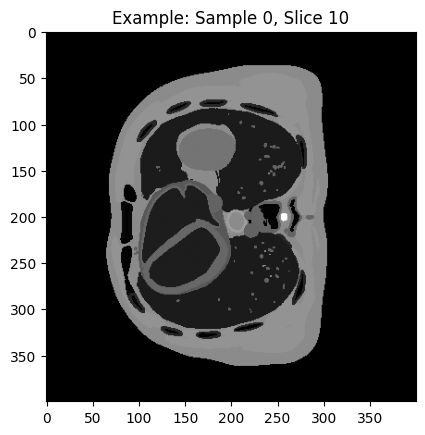

In [28]:
# Example, extracting one slice at sample 0, slice 10
ex_image = data[0, 10, :, :]
plot = plt.figure();
plot = plt.imshow(ex_image, cmap='grey');
plt.title("Example: Sample 0, Slice 10");
plt.savefig('fig/example_slice.png');
plt.show(plot)

In [ ]:
# Animation to demonstrate breathing cycle in XCAT
import matplotlib.animation as animation
from IPython.display import Image, display

images = data2[0:99, 10, :, :];

im = plt.imshow(images[0], cmap='grey');

def updateFig(f):
    im.set_array(images[f]);
    return [im];

fig = plt.gcf();
# TODO frames should be 300ms sampled, but there is something strange with the interval param
ani = animation.FuncAnimation(fig, updateFig, frames=range(99), interval=300, blit=False);
ani.save('fig/animation.gif', writer='pillow', fps=20);

plt.close(fig);
display(Image(filename='fig/animation.gif'));

# Radial MRI
(explain radial MRI, golden angle, spokes, etc. here)

Parameters:
- sample_rate: sample rate of dataset (300ms)
- frames: the number of samples in one breath cycle
- tr: repetition time, the time to acquire one spoke [s]
- breaths: the number of breaths in the simulation
- cycle_time: the time [s] of one breath
- spokes: the number of spokes collected

In [96]:
# Constants
GOLDEN_ANGLE = 111.246;
sample_rate = 0.3; # 300 ms
frames = 50; # frames to simulate

# TODO look at graphs in MATLAB to determine one breathing cycle start/end
# this is currently taking all 100 frames of around 2.5 breaths as one. 
# change to extract frames from one breath and update frames (changing fs as well to be more realistic)

tr = 0.004; # time to acquire 1 spoke [s]
breaths = 1;
cycle_time = frames * sample_rate;
spokes = (breaths * cycle_time) / tr;

print(f"Running simulation with {frames} frames at fs={sample_rate}, TR={tr}, {breaths} breaths at {cycle_time}s each: {spokes} spokes.");

angles = np.arange(spokes) * GOLDEN_ANGLE;
angles = np.mod(angles, 180.0);
assert(len(angles) == spokes);

Running simulation with 50 frames at fs=0.3, TR=0.004, 1 breaths at 15.0s each: 3750.0 spokes.


# Example: Static Image, 101 spokes

In [ ]:
# Example
ex_gt = data2[0, 10, :, :];
ex_sinogram = radon(data2[0, 10, :, :], theta=angles[0:100]);
ex_reconstructed = iradon(sinogram, theta=angles[0:100], filter_name='ramp');

fig, (ax1, ax2, ax3) = plt.subplots(1, 3);
fig.suptitle('Example Operation');

ax1.set_title('Ground Truth');
im1 = ax1.imshow(ex_gt, cmap='grey');

ax2.set_title('Sinogram (Forward Process)');
im2 = ax2.imshow(sinogram, cmap='grey');

ax3.set_title('Reconstruction (Backward Process)');
im3 = ax3.imshow(ex_reconstructed, cmap='grey');
plt.show();